# Hospital Current State and Workload

Historical operational view for nursing and Environmental Services (EVS), covering January 2017 through December 2024. Daily rows are reconstructed from monthly Virginia aggregate data; they are not live VCU census or patient-level observations. Appointment arrivals are synthetic.

This notebook combines bed census, nurse staffing requirements, EVS cleaning workload, and synthetic appointments. It describes workload and capacity patterns; it does not estimate actual cleaning turnaround, queue backlog, overtime, or revenue.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import yaml

# Support execution from either the workspace root or notebooks/.
working_directory = Path.cwd()
if (working_directory / "data").is_dir():
    project_root = working_directory
    notebook_dir = project_root / "notebooks"
elif (working_directory.parent / "data").is_dir():
    project_root = working_directory.parent
    notebook_dir = working_directory
else:
    raise FileNotFoundError("Run this notebook from the workspace root or notebooks/ folder.")

data_dir = project_root / "data"
assumptions_path = data_dir / "assumptions.yaml"
output_dir = notebook_dir / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

file_paths = {
    "beds": data_dir / "vcu_master_daily.csv",
    "nursing": data_dir / "vcu_nurse_requirements_daily.csv",
    "evs": data_dir / "vcu_cleaning_workload_daily.csv",
    "appointments": data_dir / "synthetic_appointments.csv",
}

beds = pd.read_csv(file_paths["beds"], parse_dates=["date"])
nursing = pd.read_csv(file_paths["nursing"], parse_dates=["date"])
evs = pd.read_csv(file_paths["evs"], parse_dates=["date"])
appointments = pd.read_csv(file_paths["appointments"], parse_dates=["date"])

required_columns = {
    "beds": {"date", "total_staffed_beds", "total_occupied_beds", "total_free_beds"},
    "nursing": {"date", "nurses_per_shift_min_total", "nurses_per_shift_max_total"},
    "evs": {"date", "cleaning_hours_total", "occupied_clean_minutes_total", "discharge_clean_minutes_total"},
    "appointments": {"date", "check_in_time", "appointment_id"},
}
for name, frame in {
    "beds": beds,
    "nursing": nursing,
    "evs": evs,
    "appointments": appointments,
}.items():
    missing_columns = required_columns[name] - set(frame.columns)
    if missing_columns:
        raise ValueError(f"{name} is missing required columns: {sorted(missing_columns)}")

print(f"Workspace: {project_root}")
print(f"Notebook outputs: {output_dir}")
print("Loaded row counts:", {"beds": len(beds), "nursing": len(nursing), "evs": len(evs), "appointments": len(appointments)})

Workspace: c:\Users\jhaley\captechdev\data_forge_2026
Notebook outputs: c:\Users\jhaley\captechdev\data_forge_2026\notebooks\outputs
Loaded row counts: {'beds': 2922, 'nursing': 2922, 'evs': 2922, 'appointments': 372197}


## 2. Standardize and Clean the Sources

Column names and dates are standardized before comparison. Exact duplicate rows are removed; appointments are additionally deduplicated by appointment ID. Missing numeric values are left missing rather than filled with zero, since blanks can mean unavailable or suppressed data. Appointment times contain clock time only, with no timezone or actual event-duration information.

In [2]:
frames = {
    "beds": beds,
    "nursing": nursing,
    "evs": evs,
    "appointments": appointments,
}
cleaning_report = []

for name, frame in frames.items():
    frame.columns = (
        frame.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
        .str.strip("_")
    )
    frame["date"] = pd.to_datetime(frame["date"], errors="coerce").dt.normalize()
    if frame["date"].isna().any():
        raise ValueError(f"{name} contains rows with invalid dates")

    rows_before = len(frame)
    frame.drop_duplicates(inplace=True)
    if name == "appointments":
        frame.drop_duplicates(subset=["appointment_id"], keep="first", inplace=True)
    duplicate_rows_removed = rows_before - len(frame)

    excluded_columns = {"date", "appointment_id", "category", "check_in_time"}
    for column in frame.columns:
        if column not in excluded_columns and frame[column].dtype == "object":
            frame[column] = pd.to_numeric(frame[column], errors="coerce")

    cleaning_report.append(
        {
            "source": name,
            "rows_after_deduplication": len(frame),
            "duplicate_rows_removed": duplicate_rows_removed,
            "missing_values": int(frame.isna().sum().sum()),
        }
    )

for name, frame in {"beds": beds, "nursing": nursing, "evs": evs}.items():
    if frame["date"].duplicated().any():
        raise ValueError(f"{name} has more than one row per date")

appointments["check_in_delta"] = pd.to_timedelta(
    appointments["check_in_time"].astype("string").str.strip(), errors="coerce"
)
if appointments["check_in_delta"].isna().any():
    raise ValueError("Some synthetic appointment check-in times could not be parsed")
appointments["arrival_hour"] = appointments["check_in_delta"].dt.components.hours

pd.DataFrame(cleaning_report)

,source,rows_after_deduplication,duplicate_rows_removed,missing_values
0,beds,2922,0,4380
1,nursing,2922,0,0
2,evs,2922,0,0
3,appointments,372197,0,0


## 3. Assumptions and Revenue Hypothesis

The project’s single assumptions registry is `data/assumptions.yaml`; this notebook reads it rather than creating a second assumptions file under `notebooks/`. The revenue statement is a stakeholder hypothesis: faster turnover and more available beds may enable more admissions and higher revenue. It is not measured or tested here. Demand, payer mix, reimbursement, and marginal cost data are unavailable, so no revenue proxy or financial forecast is defensible.

In [3]:
with assumptions_path.open(encoding="utf-8") as assumptions_file:
    assumptions = yaml.safe_load(assumptions_file)

business_impact = assumptions.get("business_impact", {})
revenue_hypothesis = business_impact.get("faster_turnover_may_increase_revenue")
if revenue_hypothesis is None:
    raise KeyError("Add the faster-turnover revenue hypothesis to data/assumptions.yaml")

assumption_summary = pd.DataFrame(
    [
        {"topic": "Daily census", "assumption": "Reconstructed from monthly Virginia aggregates; not live or patient-level."},
        {"topic": "Nurse staffing", "assumption": "Daily requirements use project ratio rules; delivery staffing is known to be overstated."},
        {"topic": "EVS cleaning", "assumption": "Cleaning durations are estimates; observed room-level turnaround events are unavailable."},
        {"topic": "Appointments", "assumption": "Arrival times are synthetic and use an assumed hourly profile."},
        {"topic": "Revenue", "assumption": "Faster turnover / greater availability may increase revenue; unquantified stakeholder hypothesis."},
    ]
)
assumption_summary

,topic,assumption
0,Daily census,Reconstructed from monthly Virginia aggregates...
1,Nurse staffing,Daily requirements use project ratio rules; de...
2,EVS cleaning,Cleaning durations are estimates; observed roo...
3,Appointments,Arrival times are synthetic and use an assumed...
4,Revenue,Faster turnover / greater availability may inc...


## 4. Unified Daily Operational Timeline

Census, nurse requirements, and EVS workload are each daily series. Synthetic appointments are first summarized by date and arrival hour; only their daily count is joined to the operational table. This avoids multiplying daily records by the many appointments recorded on each day.

In [4]:
daily_sources = {"beds": beds, "nursing": nursing, "evs": evs}
date_sets = {name: set(frame["date"]) for name, frame in daily_sources.items()}
date_sets["appointments"] = set(appointments["date"].unique())
base_dates = date_sets["beds"]
coverage_check = pd.DataFrame(
    [
        {
            "source": name,
            "rows_or_days": len(frame) if name == "appointments" else frame["date"].nunique(),
            "first_date": min(date_sets[name]),
            "last_date": max(date_sets[name]),
            "matches_bed_date_coverage": date_sets[name] == base_dates,
        }
        for name, frame in daily_sources.items()
    ]
    + [
        {
            "source": "appointments",
            "rows_or_days": appointments["date"].nunique(),
            "first_date": min(date_sets["appointments"]),
            "last_date": max(date_sets["appointments"]),
            "matches_bed_date_coverage": date_sets["appointments"] == base_dates,
        }
    ]
)
if not coverage_check["matches_bed_date_coverage"].all():
    raise ValueError("Source date coverage differs; review coverage_check before joining")

appointments_daily = (
    appointments.groupby("date", as_index=False)
    .agg(synthetic_appointment_count=("appointment_id", "count"))
)
appointments_hourly = (
    appointments.groupby("arrival_hour", as_index=False)
    .size()
    .rename(columns={"size": "appointment_count"})
)

nursing_columns = [
    "date",
    "census_icu",
    "nurses_per_shift_min_icu",
    "nurses_per_shift_max_icu",
    "census_med_surg",
    "nurses_per_shift_min_med_surg",
    "nurses_per_shift_max_med_surg",
    "census_labor_delivery",
    "nurses_per_shift_min_labor_delivery",
    "nurses_per_shift_max_labor_delivery",
    "census_pediatric",
    "nurses_per_shift_min_pediatric",
    "nurses_per_shift_max_pediatric",
    "nurses_per_shift_min_total",
    "nurses_per_shift_max_total",
]
operational = (
    beds.merge(nursing[nursing_columns], on="date", how="inner", validate="one_to_one")
    .merge(evs, on="date", how="inner", validate="one_to_one")
    .merge(appointments_daily, on="date", how="inner", validate="one_to_one")
    .sort_values("date")
    .reset_index(drop=True)
)
if len(operational) != len(base_dates) or operational["date"].duplicated().any():
    raise ValueError("Unified table does not have exactly one row per shared date")

print(f"Unified timeline: {operational['date'].min():%Y-%m-%d} to {operational['date'].max():%Y-%m-%d}; {len(operational):,} daily rows")
coverage_check

Unified timeline: 2017-01-01 to 2024-12-31; 2,922 daily rows


,source,rows_or_days,first_date,last_date,matches_bed_date_coverage
0,beds,2922,2017-01-01,2024-12-31,True
1,nursing,2922,2017-01-01,2024-12-31,True
2,evs,2922,2017-01-01,2024-12-31,True
3,appointments,2922,2017-01-01,2024-12-31,True


## 5. Full-History Trends

Monthly averages make long-term patterns readable while retaining all daily source rows in the unified table. Thirty-day rolling means are included for daily inspection; year-over-year changes compare each month with the same month one year earlier. These are descriptive trends, not causal estimates.

In [5]:
operational["occupancy_pct"] = (
    operational["total_occupied_beds"] / operational["total_staffed_beds"] * 100
)
operational["patients_per_min_required_nurse"] = (
    operational["total_occupied_beds"] / operational["nurses_per_shift_min_total"]
)
operational["free_beds_30d_mean"] = operational["total_free_beds"].rolling(30, min_periods=30).mean()
operational["cleaning_hours_30d_mean"] = operational["cleaning_hours_total"].rolling(30, min_periods=30).mean()

monthly = (
    operational.set_index("date")
    .resample("MS")
    .agg(
        mean_occupied_beds=("total_occupied_beds", "mean"),
        mean_free_beds=("total_free_beds", "mean"),
        mean_occupancy_pct=("occupancy_pct", "mean"),
        mean_nurses_min_per_shift=("nurses_per_shift_min_total", "mean"),
        mean_nurses_max_per_shift=("nurses_per_shift_max_total", "mean"),
        mean_patients_per_min_required_nurse=("patients_per_min_required_nurse", "mean"),
        mean_evs_cleaning_hours_per_day=("cleaning_hours_total", "mean"),
        mean_occupied_clean_hours_per_day=("occupied_clean_minutes_total", lambda values: values.mean() / 60),
        mean_discharge_clean_hours_per_day=("discharge_clean_minutes_total", lambda values: values.mean() / 60),
        synthetic_appointments_in_month=("synthetic_appointment_count", "sum"),
        mean_synthetic_appointments_per_day=("synthetic_appointment_count", "mean"),
    )
)
monthly["free_beds_yoy_change_pct"] = monthly["mean_free_beds"].pct_change(12) * 100
monthly["evs_hours_yoy_change_pct"] = monthly["mean_evs_cleaning_hours_per_day"].pct_change(12) * 100

monthly.tail()

,mean_occupied_beds,mean_free_beds,mean_occupancy_pct,mean_nurses_min_per_shift,mean_nurses_max_per_shift,mean_patients_per_min_required_nurse,mean_evs_cleaning_hours_per_day,mean_occupied_clean_hours_per_day,mean_discharge_clean_hours_per_day,synthetic_appointments_in_month,mean_synthetic_appointments_per_day,free_beds_yoy_change_pct,evs_hours_yoy_change_pct
date,,,,,,,,,,,,,
2024-08-01,670.290323,234.709677,74.065229,171.935484,258.645161,3.898745,448.862903,347.043011,101.819882,4098,132.193548,-5.518764,2.312533
2024-09-01,669.400000,235.600000,73.966851,169.800000,253.500000,3.942642,451.566667,346.311111,105.255944,4047,134.900000,-5.063801,1.695730
2024-10-01,679.612903,225.387097,75.095348,170.709677,253.483871,3.981675,454.691935,351.161290,103.530710,4193,135.258065,-9.118106,3.020498
2024-11-01,644.300000,260.700000,71.193370,161.533333,239.300000,3.989727,427.574000,332.638889,94.935428,3630,121.000000,24.379771,-8.246579
2024-12-01,651.709677,253.290323,72.012119,165.225806,246.419355,3.944735,436.036774,336.817204,99.220151,4022,129.741935,23.907212,-7.734659


## 6. Stakeholder Metrics: Nursing and EVS

The snapshot uses the latest available date, not a live hospital feed. Nurse staffing values are modeled requirements per shift, not a roster or overtime measure. EVS figures are estimated cleaning workload hours by day, not observed completed cleans, room-ready rates, turnaround times, or queue backlog.

In [6]:
latest = operational.iloc[-1]
latest_snapshot = pd.DataFrame(
    [
        {"metric": "Date", "value": latest["date"].date().isoformat(), "unit": "latest available day"},
        {"metric": "Staffed beds", "value": int(latest["total_staffed_beds"]), "unit": "beds"},
        {"metric": "Occupied beds", "value": round(latest["total_occupied_beds"], 1), "unit": "beds"},
        {"metric": "Available beds", "value": round(latest["total_free_beds"], 1), "unit": "beds"},
        {"metric": "Occupancy", "value": round(latest["occupancy_pct"], 1), "unit": "%"},
        {"metric": "Nurses required, minimum", "value": int(latest["nurses_per_shift_min_total"]), "unit": "per shift; modeled"},
        {"metric": "Nurses required, maximum", "value": int(latest["nurses_per_shift_max_total"]), "unit": "per shift; modeled"},
        {"metric": "Patients per nurse at minimum staffing", "value": round(latest["patients_per_min_required_nurse"], 2), "unit": "patients per nurse; derived"},
        {"metric": "EVS cleaning workload", "value": round(latest["cleaning_hours_total"], 1), "unit": "estimated hours per day"},
        {"metric": "Synthetic appointments", "value": int(latest["synthetic_appointment_count"]), "unit": "arrivals per day; synthetic"},
    ]
)

annual_kpis = (
    operational.assign(year=operational["date"].dt.year)
    .groupby("year", as_index=False)
    .agg(
        mean_occupied_beds=("total_occupied_beds", "mean"),
        mean_available_beds=("total_free_beds", "mean"),
        mean_occupancy_pct=("occupancy_pct", "mean"),
        mean_nurses_min_per_shift=("nurses_per_shift_min_total", "mean"),
        mean_nurses_max_per_shift=("nurses_per_shift_max_total", "mean"),
        mean_patients_per_min_required_nurse=("patients_per_min_required_nurse", "mean"),
        mean_evs_cleaning_hours_per_day=("cleaning_hours_total", "mean"),
        mean_occupied_clean_hours_per_day=("occupied_clean_minutes_total", lambda values: values.mean() / 60),
        mean_discharge_clean_hours_per_day=("discharge_clean_minutes_total", lambda values: values.mean() / 60),
        mean_synthetic_appointments_per_day=("synthetic_appointment_count", "mean"),
    )
)

latest_snapshot

,metric,value,unit
0,Date,2024-12-31,latest available day
1,Staffed beds,905,beds
2,Occupied beds,643.0,beds
3,Available beds,262.0,beds
4,Occupancy,71.0,%
5,"Nurses required, minimum",163,per shift; modeled
6,"Nurses required, maximum",246,per shift; modeled
7,Patients per nurse at minimum staffing,3.94,patients per nurse; derived
8,EVS cleaning workload,429.3,estimated hours per day
9,Synthetic appointments,118,arrivals per day; synthetic


## 7. Bed Turnover and Revenue: Data Readiness

The stated revenue assumption is retained in YAML, but the available data cannot support a turnover-speed or revenue calculation. It has daily bed availability and estimated cleaning workload, but no observed ready-to-clean/ready-bed timestamps, admission demand constrained by bed availability, payer mix, reimbursement, or marginal cost. Therefore this notebook does not create a revenue proxy or claim that extra available beds produced revenue. A future analysis would need those inputs and a defined causal design.

In [7]:
revenue_readiness = pd.DataFrame(
    [
        {"input": "Daily available beds", "present": True, "note": "Observed in the reconstructed daily series; not a revenue measure."},
        {"input": "Actual bed-turnover duration", "present": False, "note": "No room-ready timestamps or event-level cleaning records."},
        {"input": "Unmet admission demand", "present": False, "note": "Appointment arrivals are synthetic and are not inpatient demand constrained by beds."},
        {"input": "Payer mix and reimbursement", "present": False, "note": "Not included in the available files."},
        {"input": "Marginal operating cost", "present": False, "note": "Not included; additional throughput is not equivalent to net revenue."},
    ]
)
revenue_readiness

,input,present,note
0,Daily available beds,True,Observed in the reconstructed daily series; no...
1,Actual bed-turnover duration,False,No room-ready timestamps or event-level cleani...
2,Unmet admission demand,False,Appointment arrivals are synthetic and are not...
3,Payer mix and reimbursement,False,Not included in the available files.
4,Marginal operating cost,False,Not included; additional throughput is not equ...


## 8. Stakeholder Charts and Exported Artifacts

The figures summarize beds, modeled nursing requirements, estimated EVS cleaning demand, and synthetic appointment patterns. Exported tables and figures are written to `notebooks/outputs/` for review. The charts are historical operational context, not a live dashboard.

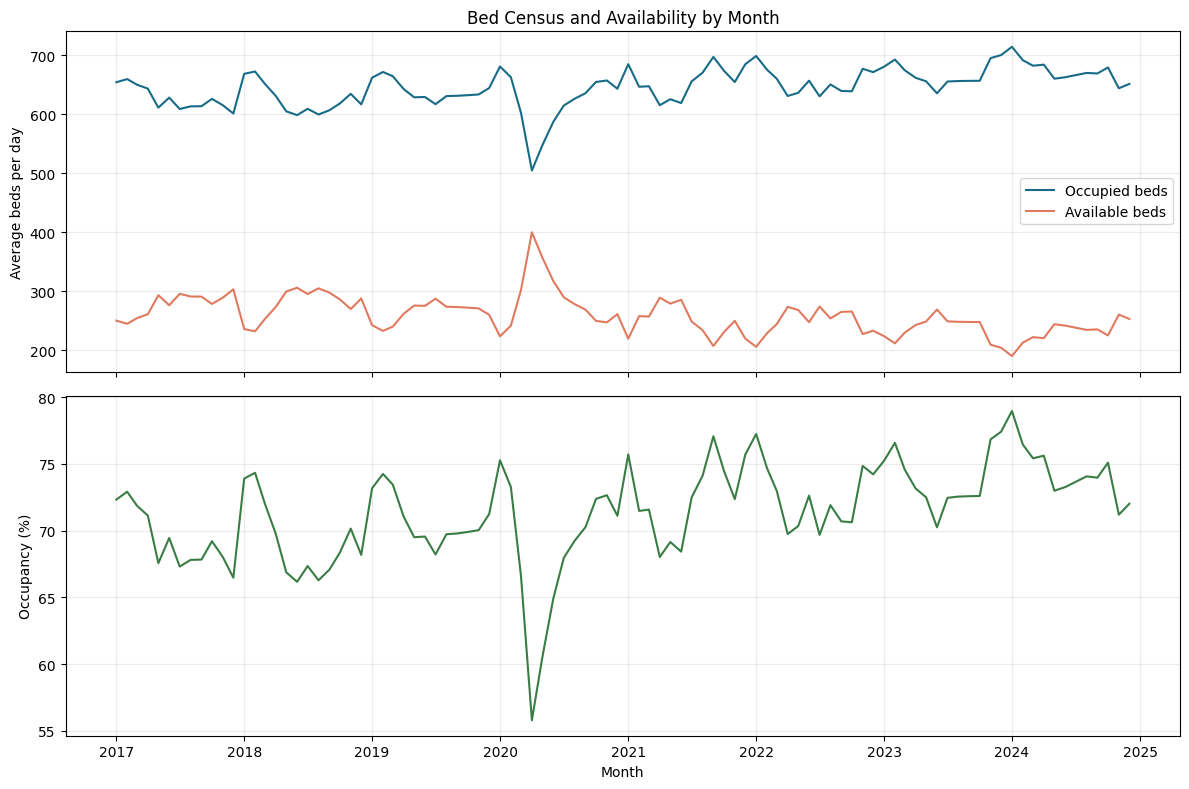

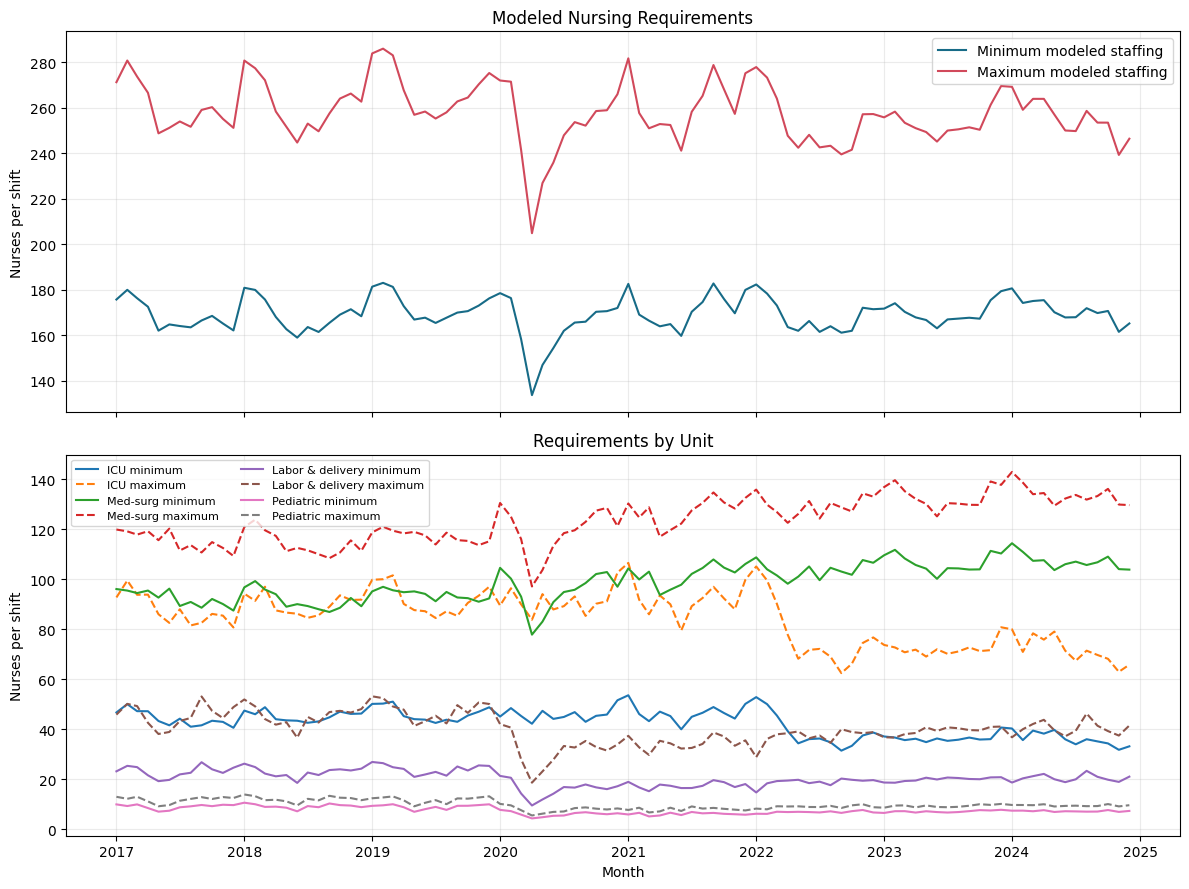

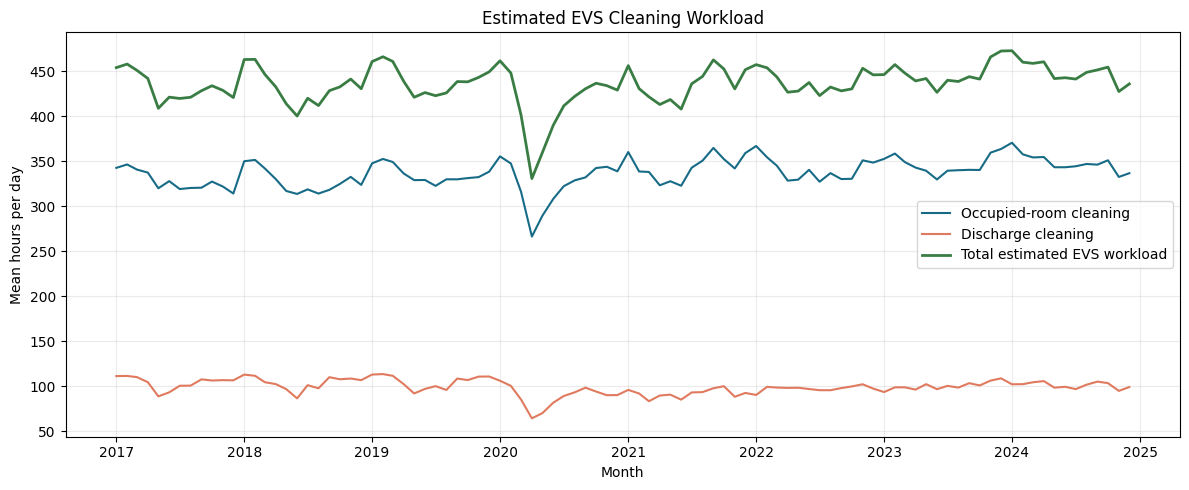

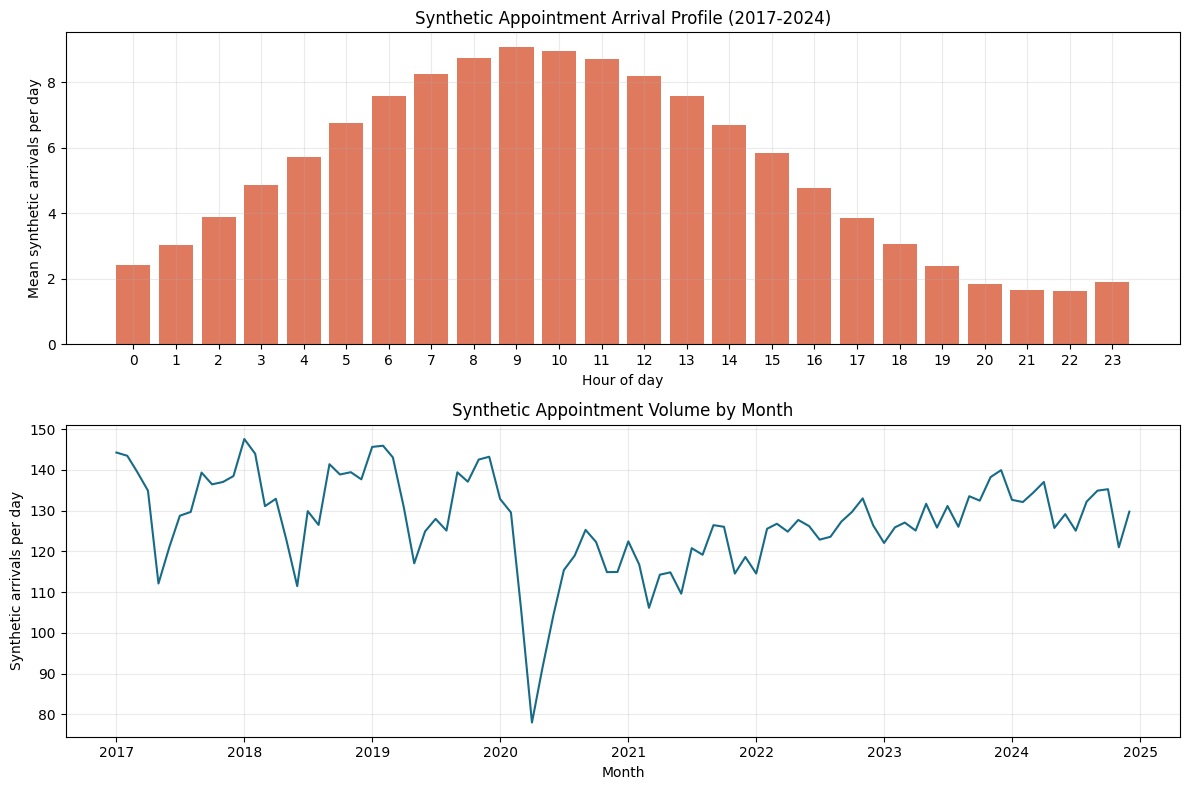

Exported artifacts:
- annual_stakeholder_kpis.csv (1,806 bytes)
- assumptions_snapshot.yaml (2,339 bytes)
- bed_availability_trend.png (177,451 bytes)
- evs_cleaning_workload_trend.png (132,181 bytes)
- latest_available_day_kpis.csv (435 bytes)
- monthly_operational_trends.csv (21,602 bytes)
- nursing_requirements_trend.png (329,032 bytes)
- synthetic_appointments_trend.png (126,293 bytes)


In [8]:
plt.rcParams.update({"figure.figsize": (12, 5), "axes.grid": True, "grid.alpha": 0.25})

# Bed availability and occupancy trends.
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(monthly.index, monthly["mean_occupied_beds"], color="#176B87", label="Occupied beds")
axes[0].plot(monthly.index, monthly["mean_free_beds"], color="#E07A5F", label="Available beds")
axes[0].set_ylabel("Average beds per day")
axes[0].set_title("Bed Census and Availability by Month")
axes[0].legend()
axes[1].plot(monthly.index, monthly["mean_occupancy_pct"], color="#3A7D44")
axes[1].set_ylabel("Occupancy (%)")
axes[1].set_xlabel("Month")
fig.tight_layout()
fig.savefig(output_dir / "bed_availability_trend.png", dpi=160, bbox_inches="tight")
plt.show()

# Nurse requirements: total range and unit-level requirements per shift.
nurse_columns_by_unit = {
    "ICU": ("nurses_per_shift_min_icu", "nurses_per_shift_max_icu"),
    "Med-surg": ("nurses_per_shift_min_med_surg", "nurses_per_shift_max_med_surg"),
    "Labor & delivery": ("nurses_per_shift_min_labor_delivery", "nurses_per_shift_max_labor_delivery"),
    "Pediatric": ("nurses_per_shift_min_pediatric", "nurses_per_shift_max_pediatric"),
}
monthly_nursing = operational.set_index("date").resample("MS").mean(numeric_only=True)
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
axes[0].plot(monthly_nursing.index, monthly_nursing["nurses_per_shift_min_total"], label="Minimum modeled staffing", color="#176B87")
axes[0].plot(monthly_nursing.index, monthly_nursing["nurses_per_shift_max_total"], label="Maximum modeled staffing", color="#D1495B")
axes[0].set_ylabel("Nurses per shift")
axes[0].set_title("Modeled Nursing Requirements")
axes[0].legend()
for unit, (minimum_column, maximum_column) in nurse_columns_by_unit.items():
    axes[1].plot(monthly_nursing.index, monthly_nursing[minimum_column], label=f"{unit} minimum")
    axes[1].plot(monthly_nursing.index, monthly_nursing[maximum_column], linestyle="--", label=f"{unit} maximum")
axes[1].set_ylabel("Nurses per shift")
axes[1].set_xlabel("Month")
axes[1].set_title("Requirements by Unit")
axes[1].legend(ncol=2, fontsize=8)
fig.tight_layout()
fig.savefig(output_dir / "nursing_requirements_trend.png", dpi=160, bbox_inches="tight")
plt.show()

# Estimated EVS cleaning demand, split by occupied-room and discharge cleaning.
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly.index, monthly["mean_occupied_clean_hours_per_day"], label="Occupied-room cleaning", color="#176B87")
ax.plot(monthly.index, monthly["mean_discharge_clean_hours_per_day"], label="Discharge cleaning", color="#E07A5F")
ax.plot(monthly.index, monthly["mean_evs_cleaning_hours_per_day"], label="Total estimated EVS workload", color="#3A7D44", linewidth=2)
ax.set_title("Estimated EVS Cleaning Workload")
ax.set_ylabel("Mean hours per day")
ax.set_xlabel("Month")
ax.legend()
fig.tight_layout()
fig.savefig(output_dir / "evs_cleaning_workload_trend.png", dpi=160, bbox_inches="tight")
plt.show()

# Synthetic arrivals: average arrivals per hour across the full period and monthly daily volume.
arrival_profile = appointments_hourly.set_index("arrival_hour")["appointment_count"].reindex(range(24), fill_value=0) / len(base_dates)
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].bar(arrival_profile.index, arrival_profile.values, color="#E07A5F")
axes[0].set_xticks(range(24))
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Mean synthetic arrivals per day")
axes[0].set_title("Synthetic Appointment Arrival Profile (2017-2024)")
axes[1].plot(monthly.index, monthly["mean_synthetic_appointments_per_day"], color="#176B87")
axes[1].set_ylabel("Synthetic arrivals per day")
axes[1].set_xlabel("Month")
axes[1].set_title("Synthetic Appointment Volume by Month")
fig.tight_layout()
fig.savefig(output_dir / "synthetic_appointments_trend.png", dpi=160, bbox_inches="tight")
plt.show()

# Export stakeholder tables and a snapshot of the assumptions used in this notebook.
latest_snapshot.to_csv(output_dir / "latest_available_day_kpis.csv", index=False)
annual_kpis.to_csv(output_dir / "annual_stakeholder_kpis.csv", index=False)
monthly.to_csv(output_dir / "monthly_operational_trends.csv", index_label="month")
assumptions_snapshot = {
    "business_impact": assumptions.get("business_impact", {}),
    "nurse_staffing": assumptions.get("nurse_staffing", {}),
    "room_cleaning": assumptions.get("room_cleaning", {}),
    "evs_staffing": assumptions.get("evs_staffing", {}),
}
with (output_dir / "assumptions_snapshot.yaml").open("w", encoding="utf-8") as snapshot_file:
    yaml.safe_dump(assumptions_snapshot, snapshot_file, sort_keys=False)

print("Exported artifacts:")
for artifact_path in sorted(output_dir.iterdir()):
    print(f"- {artifact_path.name} ({artifact_path.stat().st_size:,} bytes)")